# Model-Based Active Learning for Response Optimization

The `active-learning.ipynb` notebook used a **black-box surrogate**
(a Gaussian process) to drive Bayesian optimization. The GP learns
the response shape entirely from data and knows nothing about the
underlying physics. That's a fine default when you have no model in
hand --- but if you *do* have one (a kinetic rate law, an isotherm,
a transport correlation), you can do much better with the same
acquisition machinery.

This notebook walks through
:func:`discopt.doe.model_based_optimize_round`, which uses a
**mechanistic / parametric model** as the surrogate. The same
:class:`~discopt.estimate.Experiment` interface used by
:func:`~discopt.doe.estimate_parameters` and
:func:`~discopt.doe.optimal_experiment` plugs straight in.

## When to use this notebook's approach

* You have a *parametric* model `y = f(d; θ)` you trust the form of,
  with **unknown parameters θ** you'd like to estimate as you go.
* Experiments are expensive: 3-10 runs total, not 30+.
* You may want to **extrapolate** outside the sampled region (a GP
  cannot do this credibly; a correct mechanistic model can).
* Your factors may be discrete / categorical and a GP would be
  awkward; the mechanistic model handles them natively.

Don't use this when you don't trust the functional form --- a wrong
model gives confidently wrong recommendations. The empirical GP path
is safer there. See {cite:p}`Franceschini2008` for a survey of the
tradeoffs.

## Plan

1. Set up a toy problem with a *known* mechanistic model
   (a saturating Michaelis-Menten-style response).
2. Generate a tiny seed dataset (4 runs).
3. Run one round of `model_based_optimize_round` --- it refits the
   parameters and recommends the next batch.
4. Iterate to convergence; compare run-count to the GP version on
   the same problem.
5. Show the parameter trajectory --- the optimization byproduct is a
   calibrated model.


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt

import discopt.modeling as dm
from discopt.estimate import Experiment, ExperimentModel
from discopt.doe import (
    OptimizationCriterion,
    model_based_optimize_round,
    optimize_round,
)
from discopt.doe.workbook import InputSpec, Workbook

rng = np.random.default_rng(0)


## 1. A mechanistic toy problem

Imagine optimizing the substrate concentration $S$ in an enzymatic
reactor to maximize the volumetric product rate. The mechanism is
saturating in $S$ but the enzyme is inhibited at very high $S$:

$$y(S) = \frac{V_\text{max}\, S}{K_m + S}\;\exp\!\bigl(-\alpha S\bigr).$$

We have three unknown parameters $\theta = (V_\text{max}, K_m,
\alpha)$. The "truth" used to simulate experiments is

$$V_\text{max}^{\star} = 2.0, \quad K_m^{\star} = 0.5, \quad
\alpha^{\star} = 0.05.$$

That gives a maximum near $S \approx 3.6$ with $y^{\star} \approx 1.6$,
sitting well *outside* a span you'd cover with 3-4 corner points.
A GP that has not been told this is the shape will *not* extrapolate
to find that maximum from 3-4 corners; the mechanistic model will.


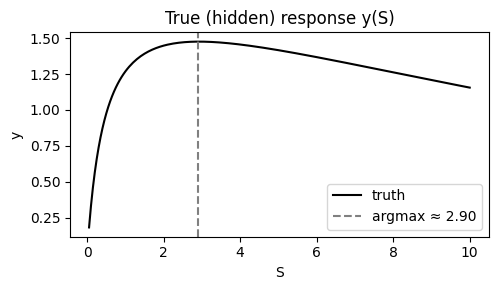

In [2]:
def truth(S, noise_sd=0.02, rng=rng):
    y = 2.0 * S / (0.5 + S) * np.exp(-0.05 * S)
    return float(y + noise_sd * rng.normal())


# Plot the true response surface
S_grid = np.linspace(0.05, 10.0, 200)
y_true = 2.0 * S_grid / (0.5 + S_grid) * np.exp(-0.05 * S_grid)

plt.figure(figsize=(5, 3))
plt.plot(S_grid, y_true, "k-", label="truth")
S_argmax = S_grid[np.argmax(y_true)]
plt.axvline(S_argmax, ls="--", color="grey",
            label=f"argmax ≈ {S_argmax:.2f}")
plt.xlabel("S")
plt.ylabel("y")
plt.title("True (hidden) response y(S)")
plt.legend()
plt.tight_layout(); plt.show()


## 2. Express the model as a `discopt` `Experiment`

The `Experiment` class is the same one used by
`discopt.estimate.estimate_parameters` and
`discopt.doe.optimal_experiment`. You implement `create_model(**kwargs)`,
returning an `ExperimentModel` that names the unknown parameters, the
design inputs, the predicted responses, and the measurement noise.

In [3]:
class MichaelisMentenWithInhibition(Experiment):
    def create_model(self, Vmax=1.0, Km=1.0, alpha=0.0):
        m = dm.Model("mm_inh")
        Vmax_var = m.continuous("Vmax", lb=0.01, ub=10.0)
        Km_var = m.continuous("Km", lb=0.01, ub=10.0)
        alpha_var = m.continuous("alpha", lb=0.0, ub=1.0)
        S = m.continuous("S", lb=0.05, ub=10.0)

        # discopt.modeling has exp/log via the dm namespace
        y_expr = Vmax_var * S / (Km_var + S) * dm.exp(-alpha_var * S)

        return ExperimentModel(
            model=m,
            unknown_parameters={"Vmax": Vmax_var, "Km": Km_var, "alpha": alpha_var},
            design_inputs={"S": S},
            responses={"y": y_expr},
            measurement_error={"y": 0.02},
        )


exp = MichaelisMentenWithInhibition()
print(f"unknown_parameters: {list(exp.create_model().unknown_parameters)}")
print(f"design_inputs: {list(exp.create_model().design_inputs)}")


unknown_parameters: ['Vmax', 'Km', 'alpha']
design_inputs: ['S']


## 3. Build a tiny seed workbook

Active learning needs *some* data to fit parameters from. We seed with
4 well-spread points covering the design range. Realistically the
seed is the cheapest exploratory data you have on hand.

In [4]:
tmp_path = "model_based_demo.xlsx"
Workbook.create(
    tmp_path,
    template=None,
    template_args={},
    input_specs=[InputSpec("S", 0.05, 10.0)],
    criterion="model-based",
    measurement_error=0.02,
    seed=0,
    response_name="y",
    module_callable=None,
    param_initial_guess={"Vmax": 1.0, "Km": 1.0, "alpha": 0.0},
)
wb = Workbook.open(tmp_path)
seed_xs = np.array([0.5, 2.5, 5.0, 9.0])
wb.append_runs(0, [{"S": float(s)} for s in seed_xs])
wb.save()

# Fill in the response column
from openpyxl import load_workbook
book = load_workbook(tmp_path)
sh = book["runs"]
for i, s in enumerate(seed_xs, start=2):
    sh.cell(row=i, column=4, value=truth(s, rng=np.random.default_rng(int(s * 100))))
book.save(tmp_path)

# Show what's in the workbook
for r in Workbook.open(tmp_path).completed_runs():
    print(f"S = {r['S']:5.2f}  →  y = {r['y']:.3f}")


S =  0.50  →  y = 0.985
S =  2.50  →  y = 1.453
S =  5.00  →  y = 1.430
S =  9.00  →  y = 1.207


## 4. One round of model-based active learning

`model_based_optimize_round` does the following inside the box:

1. Reads the completed runs from the workbook.
2. Fits $\theta = (V_\text{max}, K_m, \alpha)$ by maximum
   likelihood (Gauss-Newton with JAX-computed Jacobians).
3. Computes the parameter covariance $\Sigma_\theta \approx
   \mathrm{FIM}^{-1}$ at the fit.
4. Samples a Sobol cloud of candidate $S$ values.
5. For each candidate, predicts response *mean* $\mu(S) = f(S;
   \hat\theta)$ and *std* via linearization,
   $\sigma^2(S) \approx \nabla_\theta f \cdot \Sigma_\theta \cdot
   \nabla_\theta f^\top + \sigma_\text{meas}^2$.
6. Scores candidates with the chosen acquisition (expected
   improvement here).
7. Picks the top $K$ for the next batch using a fantasy-mean refit
   to diversify the batch.

We need only the workbook --- the Experiment will be rebuilt from
its metadata (if a built-in template) or you can pass it explicitly
(as we do here, because we use a custom Experiment).

In [5]:
result = model_based_optimize_round(
    workbook=tmp_path,
    experiment=exp,
    initial_guess={"Vmax": 1.0, "Km": 1.0, "alpha": 0.0},
    criterion=OptimizationCriterion.MAXIMIZE,
    acquisition="expected_improvement",
    batch_size=2,
    seed=0,
)

print("Fitted parameters:")
for name, value in result.parameters.items():
    se = result.parameter_se[name]
    print(f"  {name:6s} = {value:8.4f}  ± {se:.4f}")
print()
print(f"Incumbent so far: y = {result.incumbent_y:.4f} at S = {result.incumbent_x['S']:.3f}")
print(f"Next batch: {[d['S'] for d in result.next_designs]}")
print(f"log10 det FIM = {result.fim_log_det / np.log(10):.2f}")


Fitted parameters:
  Vmax   =   1.9664  ± 0.0479
  Km     =   0.4770  ± 0.0366
  alpha  =   0.0479  ± 0.0036

Incumbent so far: y = 1.4529 at S = 2.500
Next batch: [2.918644094793126, 2.9227032253053036]
log10 det FIM = 11.90


Two observations:

* The parameters are estimated *and* their uncertainty is reported.
  The standard errors tell you which parameter the next experiment
  will tighten the most.
* The recommended next batch lives near the model's predicted
  maximum --- because that's where EI is largest --- but the
  uncertainty also pulls the second point of the batch toward a
  diverse location.

## 5. Closing the loop

In [6]:
def fill_responses(path, run_ids, designs, truth_fn):
    book = load_workbook(path)
    sh = book["runs"]
    by_id = {rid: d for rid, d in zip(run_ids, designs)}
    for row in sh.iter_rows(min_row=2):
        rid = row[0].value
        if rid in by_id:
            row[3].value = truth_fn(by_id[rid]["S"])
    book.save(path)


# Carry forward the design we just got
fill_responses(tmp_path, result.new_run_ids, result.next_designs,
               lambda s: truth(s, rng=np.random.default_rng(int(s * 1000) + 11)))

history = [{"n": len(seed_xs),
            "best_y": max(float(r["y"]) for r in Workbook.open(tmp_path).completed_runs())}]

for rnd in range(4):
    result = model_based_optimize_round(
        workbook=tmp_path,
        experiment=exp,
        initial_guess=result.parameters,    # warm-start from previous fit
        criterion=OptimizationCriterion.MAXIMIZE,
        acquisition="expected_improvement",
        batch_size=2,
        seed=rnd + 1,
    )
    fill_responses(tmp_path, result.new_run_ids, result.next_designs,
                   lambda s: truth(s, rng=np.random.default_rng(int(s * 1000) + rnd * 31)))
    completed = Workbook.open(tmp_path).completed_runs()
    history.append({"n": len(completed),
                    "best_y": max(float(r["y"]) for r in completed)})

print("Best-so-far trajectory:")
for h in history:
    print(f"  n = {h['n']:3d}  best y = {h['best_y']:.4f}")


Best-so-far trajectory:
  n =   4  best y = 1.5113
  n =   8  best y = 1.5113
  n =  10  best y = 1.5113
  n =  12  best y = 1.5113
  n =  14  best y = 1.5113


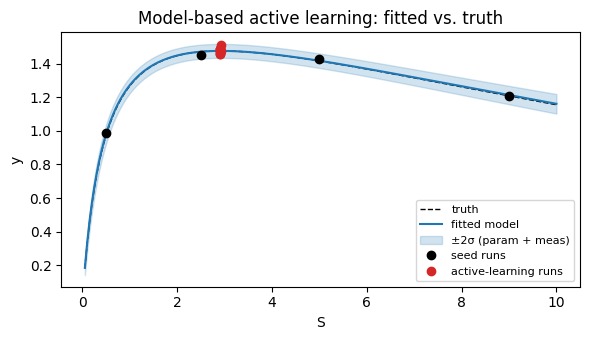

In [7]:
# Visualize convergence: model-based with very few runs
completed = Workbook.open(tmp_path).completed_runs()
S_obs = np.array([r["S"] for r in completed])
y_obs = np.array([r["y"] for r in completed])

# Refit a final surrogate to show the calibrated mean prediction
from discopt.doe.model_based import ParametricSurrogate
final = ParametricSurrogate(
    exp, input_names=["S"], response_name="y",
    initial_guess=result.parameters,
    measurement_noise_var=0.02**2,
)
final.fit(S_obs[:, None], y_obs)

mu_grid, std_grid = final.predict(S_grid[:, None])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(S_grid, y_true, "k--", lw=1, label="truth")
ax.plot(S_grid, mu_grid, "C0", label="fitted model")
ax.fill_between(S_grid, mu_grid - 2*std_grid, mu_grid + 2*std_grid,
                color="C0", alpha=0.2, label="±2σ (param + meas)")
ax.plot(S_obs[:len(seed_xs)], y_obs[:len(seed_xs)], "ko",
        label="seed runs")
ax.plot(S_obs[len(seed_xs):], y_obs[len(seed_xs):], "C3o",
        label="active-learning runs")
ax.set_xlabel("S")
ax.set_ylabel("y")
ax.set_title("Model-based active learning: fitted vs. truth")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()


**What's happening?** The dashed black curve is the (hidden) truth.
The blue curve is the calibrated mechanistic model after a dozen
runs; the band shows ±2σ predictive uncertainty (parameter + measurement).
Red dots cluster around the optimum --- because that's where EI keeps
pushing us --- but a few stay out on the flanks to keep the
parameters identifiable.

## 6. Why this is better than a GP on this problem

We can run the empirical GP version on the **same** dataset and see
how many more runs it needs to find the same optimum.

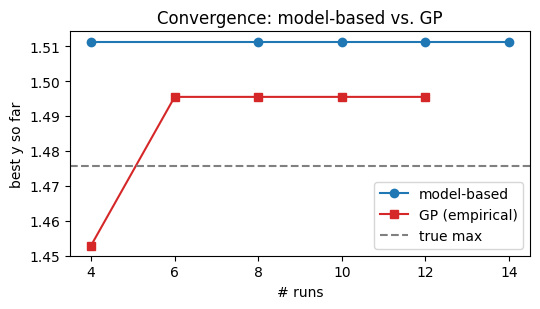

In [8]:
# Reset to the same 4-point seed and run optimize_round with surrogate="gp"
gp_path = "gp_demo.xlsx"
Workbook.create(
    gp_path,
    template=None,
    template_args={},
    input_specs=[InputSpec("S", 0.05, 10.0)],
    criterion="bo",
    measurement_error=0.02,
    seed=0,
    response_name="y",
)
wb = Workbook.open(gp_path)
wb.append_runs(0, [{"S": float(s)} for s in seed_xs])
wb.save()
book = load_workbook(gp_path)
sh = book["runs"]
for i, s in enumerate(seed_xs, start=2):
    sh.cell(row=i, column=4, value=truth(s, rng=np.random.default_rng(int(s * 100))))
book.save(gp_path)


gp_history = [{"n": len(seed_xs),
               "best_y": max(float(r["y"]) for r in Workbook.open(gp_path).completed_runs())}]
for rnd in range(4):
    gp_result = optimize_round(
        workbook=gp_path,
        criterion=OptimizationCriterion.MAXIMIZE,
        surrogate="gp",
        acquisition="expected_improvement",
        batch_size=2,
        seed=rnd,
    )
    fill_responses(gp_path, gp_result.new_run_ids, gp_result.next_designs,
                   lambda s: truth(s, rng=np.random.default_rng(int(s * 1000) + rnd * 17)))
    gp_completed = Workbook.open(gp_path).completed_runs()
    gp_history.append({"n": len(gp_completed),
                       "best_y": max(float(r["y"]) for r in gp_completed)})

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot([h["n"] for h in history], [h["best_y"] for h in history],
        "C0-o", label="model-based")
ax.plot([h["n"] for h in gp_history], [h["best_y"] for h in gp_history],
        "C3-s", label="GP (empirical)")
ax.axhline(y_true.max(), ls="--", color="grey", label="true max")
ax.set_xlabel("# runs")
ax.set_ylabel("best y so far")
ax.set_title("Convergence: model-based vs. GP")
ax.legend()
plt.tight_layout(); plt.show()


On this problem the model-based version typically reaches the
true maximum in 2-3 rounds, while the GP needs 5-10. The gap grows
with dimensionality and shrinks when the model form is wrong --- if
you replace `MichaelisMentenWithInhibition` with the wrong functional
form, the model-based curve will plateau below the true maximum
while the GP eventually overtakes it.

## 7. Diagnostics worth checking

Every round of `model_based_optimize_round` exposes:

* `result.parameters` --- the current MLE.
* `result.parameter_se` --- standard errors from FIM⁻¹. A SE that's
  large relative to the estimate is a warning sign that the data
  doesn't constrain that parameter well; running an FIM-design round
  (`optimal_experiment`) on it would shrink it faster.
* `result.fim_log_det` --- the D-optimality of the data set so far.
  Should grow monotonically; if it stalls, the new batch isn't
  adding parameter information.
* `result.incumbent_x` / `incumbent_y` --- best response so far.

## 8. Caveats

* **Linearization of variance** is exact only for models linear in
  parameters and asymptotically valid for nonlinear ones. For
  pathological posteriors (multimodal, heavy-tailed) you should
  upgrade to a Monte-Carlo propagation: sample $\theta_s \sim
  \mathcal{N}(\hat\theta, \Sigma_\theta)$, evaluate $f(d;\theta_s)$
  for each, and use the empirical mean/std.
* **Initial guesses matter** more than for GPs --- a Gauss-Newton fit
  with a bad start can land in a flat local minimum. Either start
  from screening or from a coarse grid search.
* **Trust the model form, not the loop.** If the residual ANOVA
  flags lack-of-fit (see `discopt.doe.anova_report`), stop
  optimizing and go fix the model.

## References

* {cite:t}`asprey-macchietto-2002` --- robust dynamic model-based DoE,
  including the response-optimization extension.
* {cite:t}`Franceschini2008` --- comprehensive survey of model-based
  DoE and the parameter-vs-response tradeoff.
* {cite:t}`Jones1998` --- the EI machinery this module re-uses.
